In [1]:
import torch, random
from statistics import mean
from cebmf_torch import cEBMF
import matplotlib.pyplot as plt
# ---- config
NUM_RUNS   = 20
N, P       = 50, 40
NOISE_STD  =  .1
MAXIT      = 50
TOL        = 1e-9   # numerical tolerance for strictness

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

def is_strictly_increasing(xs, tol=0.0001):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] - tol for t in range(len(xs)-1))

def is_strictly_decreasing(xs, tol=0.001):
    # xs[t+1] < xs[t] - tol  for all t
    return all(xs[t+1] < xs[t] + tol for t in range(len(xs)-1))

def one_run(seed):
    # reproducibility
    random.seed(seed)
    torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
    u = torch.rand(N, device=device)
    v = torch.rand(P, device=device)
    Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

    model = cEBMF(data=Y, K=5, prior_F="exp",
                 prior_L="exp") 
    model.fit(maxit=MAXIT)

    loss_hist = model.obj                       # your stored objective = negative ELBO
    return(loss_hist)
 


results=[]

for i in range(NUM_RUNS):
    results.append( one_run(i))
 

c:\Users\willi\miniconda3\envs\cebmf\Lib\site-packages\torch\utils\_contextlib.py:124: UserWarning: Factors not initialized; using SVD initialization.
  return func(*args, **kwargs)
c:\Users\willi\miniconda3\envs\cebmf\Lib\site-packages\torch\utils\_contextlib.py:124: UserWarning: Factors not initialized; using SVD initialization.
  return func(*args, **kwargs)


In [2]:
import matplotlib.pyplot as plt

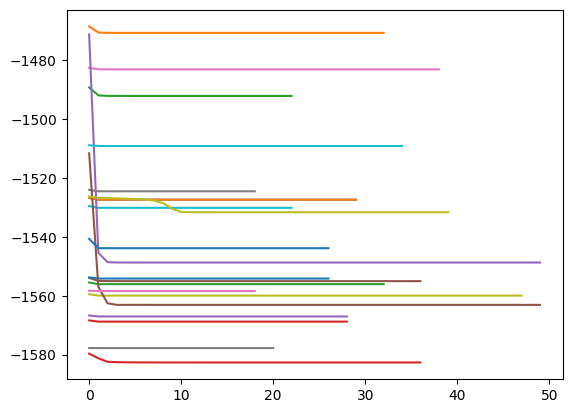

In [11]:
plt.plot(results[0])
for i in range(NUM_RUNS):
    plt.plot(results[i])

In [4]:
h=0

for i in range(NUM_RUNS):
    if (is_strictly_decreasing(results[i], tol=0.1))== False:
        h=h+1
print(h)

0


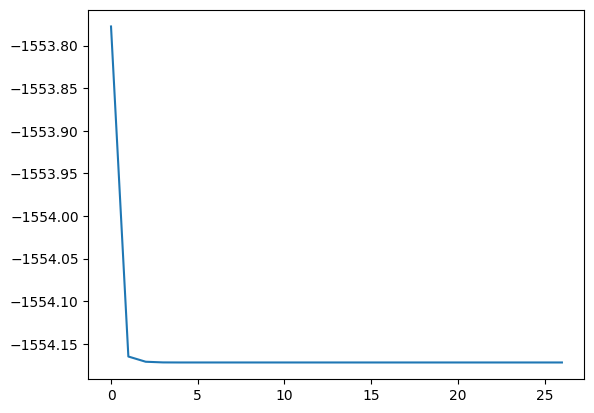

In [5]:
plt.plot(results[9])

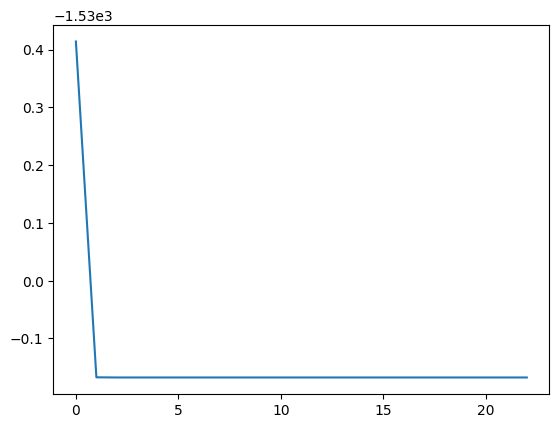

In [6]:
plt.plot(results[8])

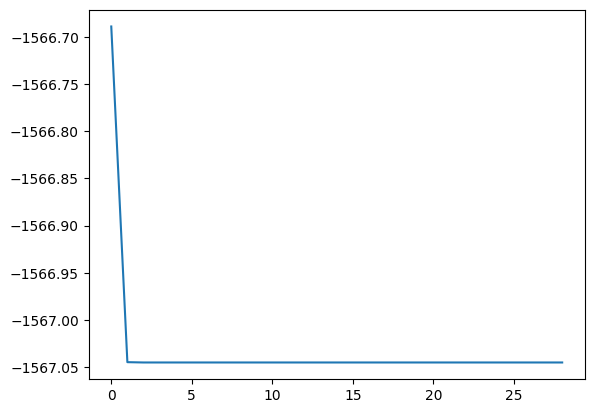

In [7]:
plt.plot(results[3])

In [8]:
seed=1
random.seed(seed)
torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
u = torch.rand(N, device=device)
v = torch.rand(P, device=device)
Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

model = cEBMF(data=Y, K=5, prior_F="exp",
                 prior_L="exp") 
model.fit(maxit=50)

CEBMFResult(L=tensor([[0.0267],
        [0.1048],
        [0.1046],
        [0.0755],
        [0.2714],
        [0.0202],
        [0.2220],
        [0.3261],
        [0.2786],
        [0.2490],
        [0.2373],
        [0.1595],
        [0.3353],
        [0.1958],
        [0.0543],
        [0.0714],
        [0.3109],
        [0.0891],
        [0.2296],
        [0.3224],
        [0.4292],
        [0.4727],
        [0.4080],
        [0.3983],
        [0.4068],
        [0.0729],
        [0.0687],
        [0.4695],
        [0.3714],
        [0.2230],
        [0.1778],
        [0.2010],
        [0.3737],
        [0.4263],
        [0.4434],
        [0.0717],
        [0.4506],
        [0.1558],
        [0.2001],
        [0.1317],
        [0.1097],
        [0.1059],
        [0.1458],
        [0.1935],
        [0.1606],
        [0.1326],
        [0.3676],
        [0.1470],
        [0.1925],
        [0.1405]]), F=tensor([[1.4733],
        [0.5581],
        [0.8545],
        [1.8248],
        [1

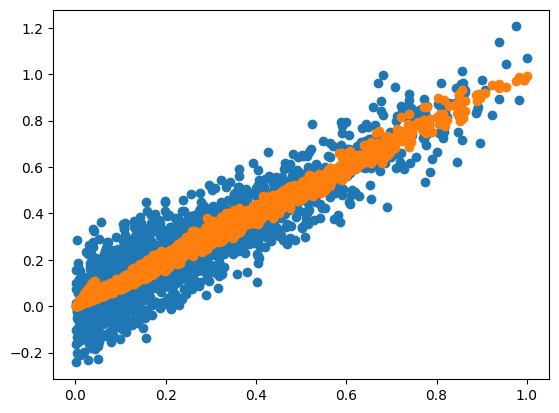

In [9]:
model._update_fitted_value()
plt.scatter(model.Y_fit, Y)
plt.scatter(model.Y_fit, torch.outer(u, v) )

In [10]:
model.obj

[-1555.4973748604384,
 -1556.0684336532534,
 -1556.068699007119,
 -1556.0686990941385,
 -1556.0686990949105,
 -1556.068699095506,
 -1556.068699096095,
 -1556.0686990966801,
 -1556.068699097259,
 -1556.068699097834,
 -1556.0686990984054,
 -1556.06869909897,
 -1556.0686990995302,
 -1556.0686991000873,
 -1556.0686991006387,
 -1556.068699101185,
 -1556.0686991017271,
 -1556.068699102266,
 -1556.0686991027978,
 -1556.0686991033267,
 -1556.0686991038506,
 -1556.0686991043708,
 -1556.0686991048865,
 -1556.0686991053976,
 -1556.0686991059038,
 -1556.0686991064065,
 -1556.068699106905,
 -1556.0686991073994,
 -1556.0686991078896,
 -1556.068699108376,
 -1556.0686991088578,
 -1556.0686991093357,
 -1556.0686991098087]